# Deep Learning Fundamentals

This notebook covers core deep learning concepts implemented from scratch using numpy, including perceptrons, activation functions, backpropagation, weight initialization, and loss functions.


📺 **Video Lecture:** [https://youtu.be/96bvudFrdhg](https://youtu.be/96bvudFrdhg)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle
from sklearn.datasets import make_classification, make_moons
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Activation Functions Visualization

In [2]:
# Define activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def gelu(x):
    return x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3))) / 2

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

def relu_derivative(x):
    return (x > 0).astype(float)

print('Activation functions defined.')

Activation functions defined.


## 2. Plot Activation Functions and Derivatives

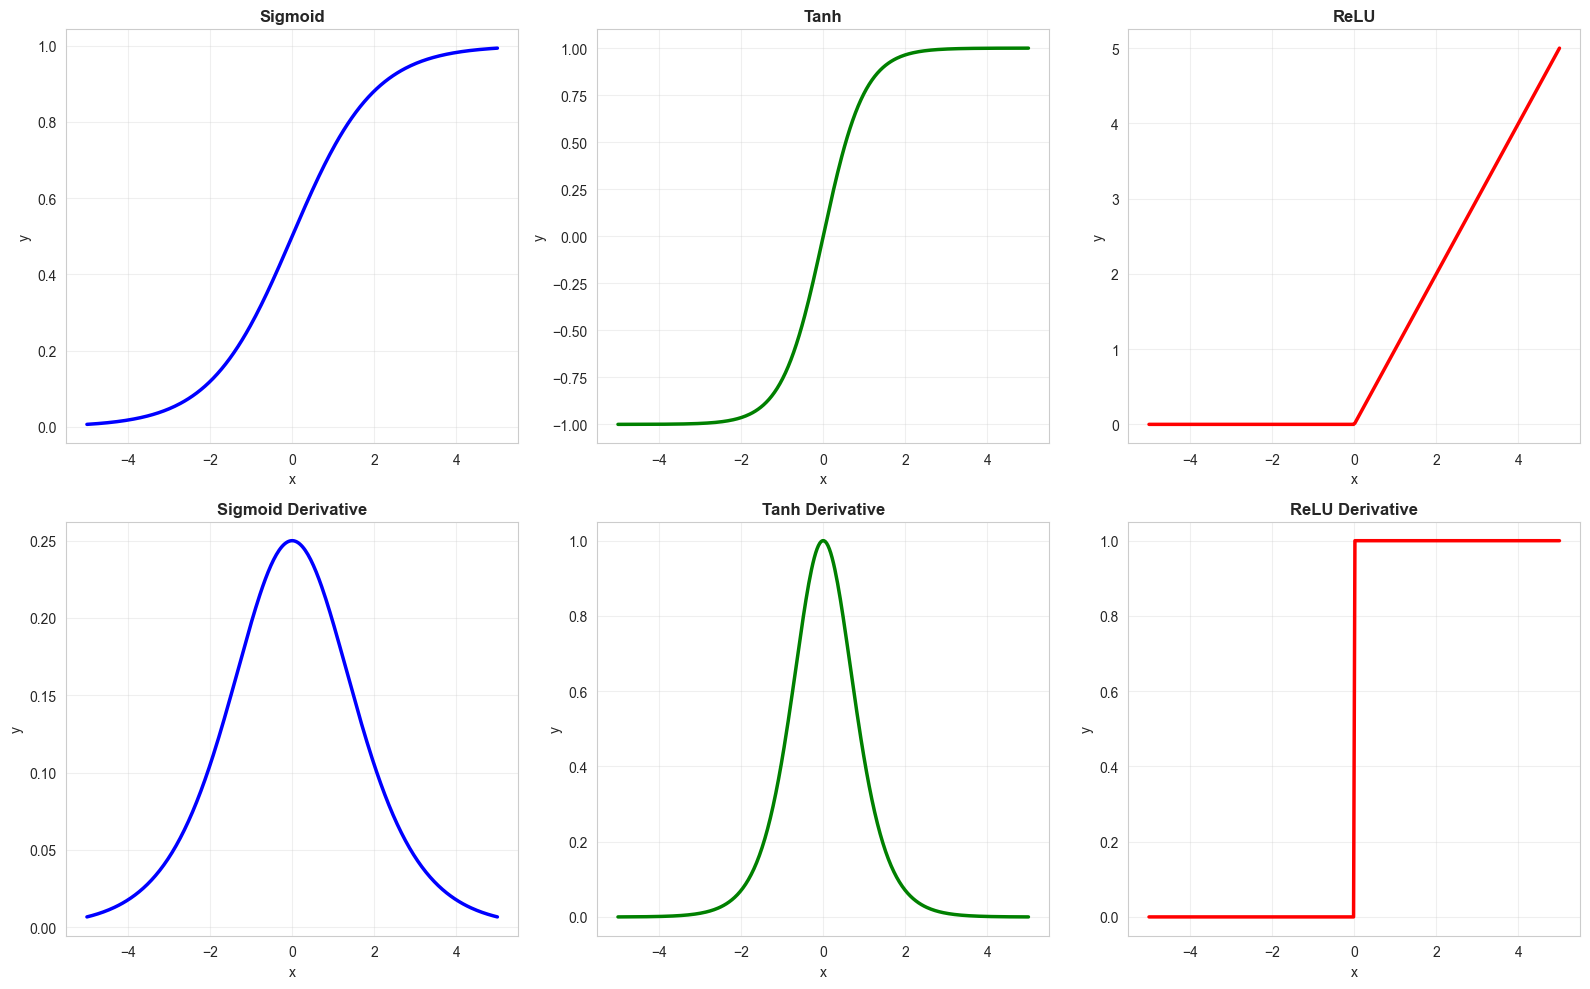

In [3]:
x = np.linspace(-5, 5, 300)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].plot(x, sigmoid(x), linewidth=2.5, color='blue')
axes[0, 0].set_title('Sigmoid', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(x, tanh(x), linewidth=2.5, color='green')
axes[0, 1].set_title('Tanh', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(x, relu(x), linewidth=2.5, color='red')
axes[0, 2].set_title('ReLU', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].plot(x, sigmoid_derivative(x), linewidth=2.5, color='blue')
axes[1, 0].set_title('Sigmoid Derivative', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(x, tanh_derivative(x), linewidth=2.5, color='green')
axes[1, 1].set_title('Tanh Derivative', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(x, relu_derivative(x), linewidth=2.5, color='red')
axes[1, 2].set_title('ReLU Derivative', fontsize=12, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()

## 3. Leaky ReLU and GELU Visualization

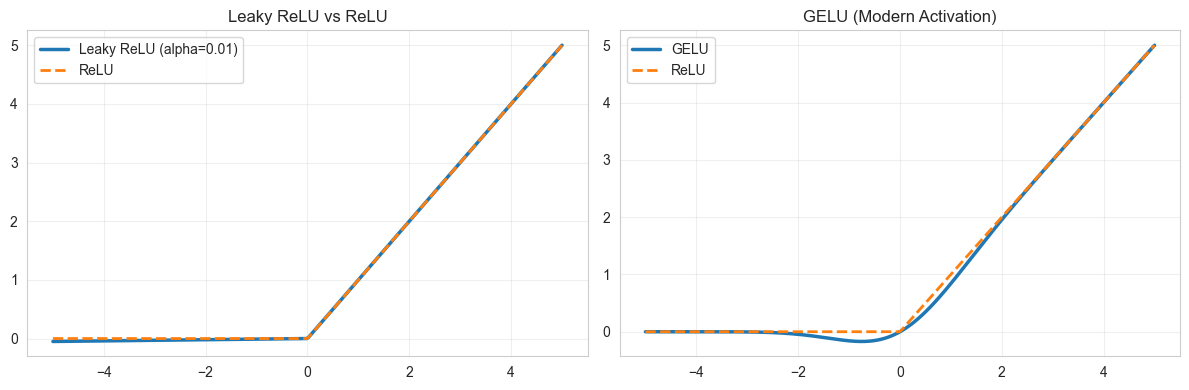

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, leaky_relu(x, alpha=0.01), label='Leaky ReLU (alpha=0.01)', linewidth=2.5)
axes[0].plot(x, relu(x), label='ReLU', linewidth=2, linestyle='--')
axes[0].set_title('Leaky ReLU vs ReLU')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(x, gelu(x), linewidth=2.5, label='GELU')
axes[1].plot(x, relu(x), linewidth=2, linestyle='--', label='ReLU')
axes[1].set_title('GELU (Modern Activation)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Perceptron Implementation

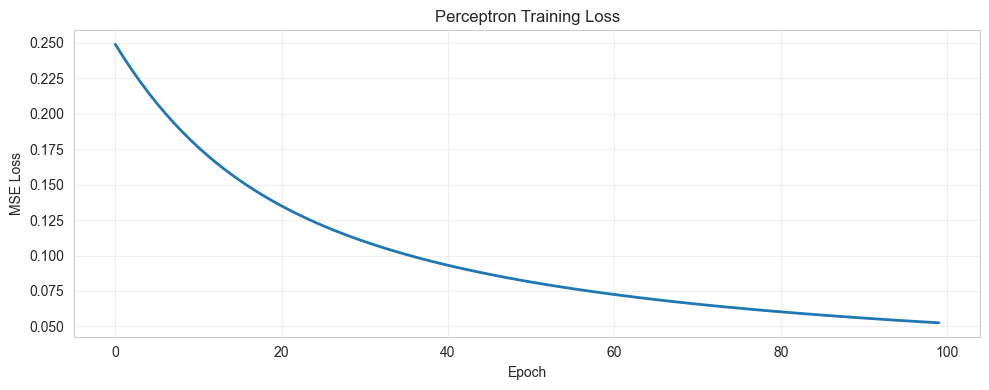

Perceptron Training Accuracy: 0.9600


In [5]:
class Perceptron:
    def __init__(self, input_size):
        self.weights = np.random.randn(input_size) * 0.01
        self.bias = 0
    
    def forward(self, X):
        self.z = np.dot(X, self.weights) + self.bias
        self.activation = sigmoid(self.z)
        return self.activation
    
    def backward(self, X, y, learning_rate=0.01):
        m = X.shape[0]
        dz = self.activation - y
        dw = (1/m) * np.dot(X.T, dz)
        db = (1/m) * np.sum(dz)
        self.weights -= learning_rate * dw
        self.bias -= learning_rate * db
        return np.mean((self.activation - y)**2)

X, y = make_classification(n_samples=100, n_features=2, n_informative=2,
                          n_redundant=0, random_state=42)

scaler = StandardScaler()
X = scaler.fit_transform(X)

perceptron = Perceptron(input_size=2)
losses = []

for epoch in range(100):
    perceptron.forward(X)
    loss = perceptron.backward(X, y, learning_rate=0.1)
    losses.append(loss)

plt.figure(figsize=(10, 4))
plt.plot(losses, linewidth=2)
plt.title('Perceptron Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

predictions = perceptron.forward(X)
accuracy = np.mean((predictions > 0.5) == y)
print(f'Perceptron Training Accuracy: {accuracy:.4f}')

## 5. Loss Functions

In [6]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def cross_entropy_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

y_true = np.array([0, 1, 1, 0, 1]).reshape(-1, 1)
y_pred_good = np.array([0.1, 0.9, 0.8, 0.2, 0.85]).reshape(-1, 1)
y_pred_bad = np.array([0.9, 0.1, 0.2, 0.8, 0.3]).reshape(-1, 1)

print('Loss Function Comparison:')
print('Good Predictions:')
print(f'  MSE: {mean_squared_error(y_true, y_pred_good):.4f}')
print(f'  Cross-Entropy: {cross_entropy_loss(y_true, y_pred_good):.4f}')
print('Bad Predictions:')
print(f'  MSE: {mean_squared_error(y_true, y_pred_bad):.4f}')
print(f'  Cross-Entropy: {cross_entropy_loss(y_true, y_pred_bad):.4f}')

Loss Function Comparison:
Good Predictions:
  MSE: 0.0245
  Cross-Entropy: 0.1639
Bad Predictions:
  MSE: 0.6780
  Cross-Entropy: 1.8056


## 6. Two-Layer Network

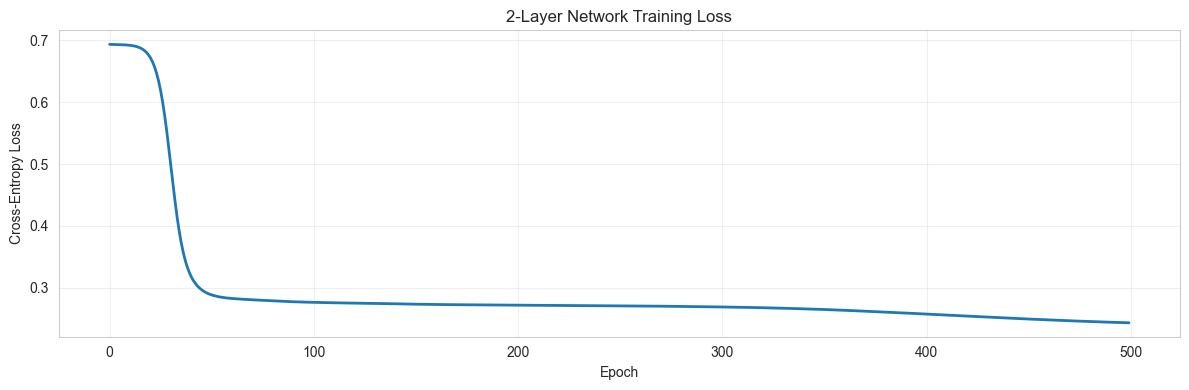

Network Training Accuracy: 0.8800


In [7]:
class TwoLayerNN:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
    
    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = relu(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2
    
    def backward(self, X, y, learning_rate=0.01):
        m = X.shape[0]
        dz2 = self.a2 - y
        dW2 = (1/m) * np.dot(self.a1.T, dz2)
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * relu_derivative(self.z1)
        dW1 = (1/m) * np.dot(X.T, dz1)
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        loss = cross_entropy_loss(y, self.a2)
        return loss

X_train, y_train = make_moons(n_samples=200, noise=0.1, random_state=42)
y_train = y_train.reshape(-1, 1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

nn = TwoLayerNN(input_size=2, hidden_size=16, output_size=1)
losses = []

for epoch in range(500):
    nn.forward(X_train)
    loss = nn.backward(X_train, y_train, learning_rate=0.5)
    losses.append(loss)

plt.figure(figsize=(12, 4))
plt.plot(losses, linewidth=2)
plt.title('2-Layer Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

predictions = nn.forward(X_train) > 0.5
accuracy = np.mean(predictions == y_train)
print(f'Network Training Accuracy: {accuracy:.4f}')

## 7. Vanishing Gradient Problem

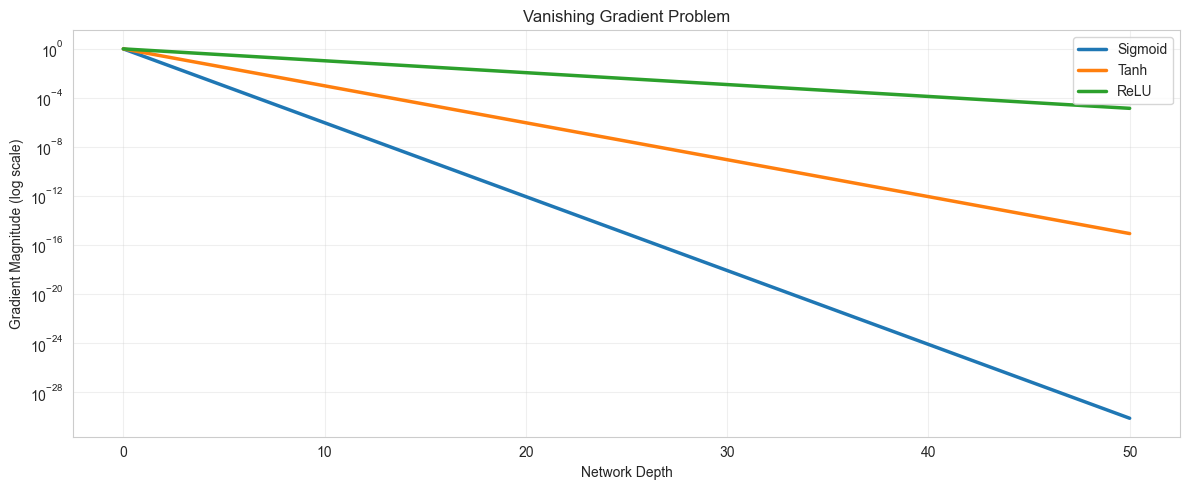

Gradient flow after layers:
Sigmoid - 10 layers: 9.54e-07
Sigmoid - 50 layers: 7.89e-31
ReLU - 50 layers: 0.0000


In [8]:
def compute_gradient_flow(depth, activation_fn='sigmoid'):
    x = 1.0
    gradients = [x]
    
    for layer in range(depth):
        if activation_fn == 'sigmoid':
            x = x * 0.25
        elif activation_fn == 'tanh':
            x = x * 0.5
        elif activation_fn == 'relu':
            x = x * 0.8
        gradients.append(x)
    
    return np.array(gradients)

depths = np.arange(0, 51)
gradients_sigmoid = np.array([compute_gradient_flow(d, 'sigmoid')[-1] for d in depths])
gradients_tanh = np.array([compute_gradient_flow(d, 'tanh')[-1] for d in depths])
gradients_relu = np.array([compute_gradient_flow(d, 'relu')[-1] for d in depths])

plt.figure(figsize=(12, 5))
plt.semilogy(depths, gradients_sigmoid, linewidth=2.5, label='Sigmoid')
plt.semilogy(depths, gradients_tanh, linewidth=2.5, label='Tanh')
plt.semilogy(depths, gradients_relu, linewidth=2.5, label='ReLU')
plt.title('Vanishing Gradient Problem')
plt.xlabel('Network Depth')
plt.ylabel('Gradient Magnitude (log scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Gradient flow after layers:')
print(f'Sigmoid - 10 layers: {gradients_sigmoid[10]:.2e}')
print(f'Sigmoid - 50 layers: {gradients_sigmoid[50]:.2e}')
print(f'ReLU - 50 layers: {gradients_relu[50]:.4f}')

## 8. Weight Initialization Strategies

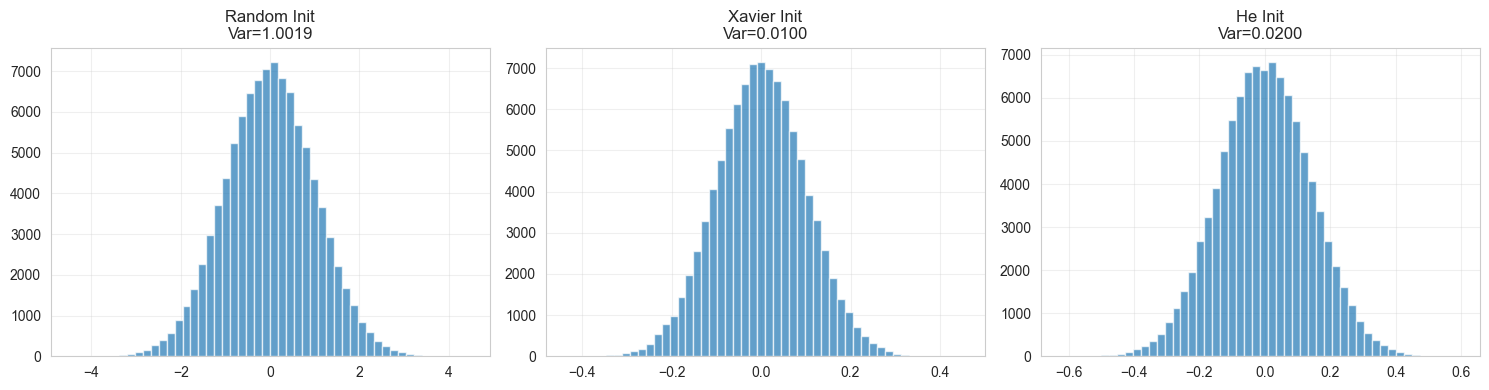

Weight Initialization:
Random - Std: 1.0009
Xavier - Std: 0.0999
He (ReLU) - Std: 0.1414


In [9]:
def visualize_weight_init(n_neurons=1000, init_method='random'):
    input_size = 100
    
    if init_method == 'random':
        weights = np.random.randn(input_size, n_neurons) * 1.0
    elif init_method == 'xavier':
        weights = np.random.randn(input_size, n_neurons) * np.sqrt(1.0 / input_size)
    elif init_method == 'he':
        weights = np.random.randn(input_size, n_neurons) * np.sqrt(2.0 / input_size)
    
    return weights

weights_random = visualize_weight_init(n_neurons=1000, init_method='random')
weights_xavier = visualize_weight_init(n_neurons=1000, init_method='xavier')
weights_he = visualize_weight_init(n_neurons=1000, init_method='he')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(weights_random.flatten(), bins=50, alpha=0.7)
axes[0].set_title(f'Random Init\nVar={weights_random.var():.4f}')
axes[0].grid(True, alpha=0.3)

axes[1].hist(weights_xavier.flatten(), bins=50, alpha=0.7)
axes[1].set_title(f'Xavier Init\nVar={weights_xavier.var():.4f}')
axes[1].grid(True, alpha=0.3)

axes[2].hist(weights_he.flatten(), bins=50, alpha=0.7)
axes[2].set_title(f'He Init\nVar={weights_he.var():.4f}')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Weight Initialization:')
print(f'Random - Std: {weights_random.std():.4f}')
print(f'Xavier - Std: {weights_xavier.std():.4f}')
print(f'He (ReLU) - Std: {weights_he.std():.4f}')

## 9. Key Takeaways

In [10]:
summary = '''
DEEP LEARNING FUNDAMENTALS - KEY CONCEPTS:

1. ACTIVATION FUNCTIONS:
   - Sigmoid: Vanishing gradient, 0-1 range
   - Tanh: Zero-centered, still has gradient issues
   - ReLU: Efficient, sparse activations
   - Leaky ReLU: Fixes dying ReLU problem
   - GELU: Modern, used in transformers

2. BACKPROPAGATION:
   - Forward: compute activations
   - Backward: compute gradients via chain rule
   - Gradient descent: update weights

3. LOSS FUNCTIONS:
   - MSE: Regression, differentiable
   - Cross-Entropy: Classification, probabilistic

4. VANISHING GRADIENT:
   - Gradients shrink in deep networks
   - ReLU mitigates this problem
   - Use residual connections, batch norm

5. WEIGHT INITIALIZATION:
   - Xavier: For sigmoid/tanh
   - He: For ReLU
   - Proper init ensures training stability
'''

print(summary)


DEEP LEARNING FUNDAMENTALS - KEY CONCEPTS:

1. ACTIVATION FUNCTIONS:
   - Sigmoid: Vanishing gradient, 0-1 range
   - Tanh: Zero-centered, still has gradient issues
   - ReLU: Efficient, sparse activations
   - Leaky ReLU: Fixes dying ReLU problem
   - GELU: Modern, used in transformers

2. BACKPROPAGATION:
   - Forward: compute activations
   - Backward: compute gradients via chain rule
   - Gradient descent: update weights

3. LOSS FUNCTIONS:
   - MSE: Regression, differentiable
   - Cross-Entropy: Classification, probabilistic

4. VANISHING GRADIENT:
   - Gradients shrink in deep networks
   - ReLU mitigates this problem
   - Use residual connections, batch norm

5. WEIGHT INITIALIZATION:
   - Xavier: For sigmoid/tanh
   - He: For ReLU
   - Proper init ensures training stability



---

<small><em>© 2026 AI Nirvana · Disclaimer: Provided as is. No liability assumed.</em></small>